let's implement an MLP in JAX!

in this implementation, we'll create a 3-layer MLP with 100 weights at each layer.

In [129]:
import jax
import jax.numpy as jnp
import jax.random as random

import matplotlib.pyplot as plt

in this case, we'll make two toruses - non-linearly separable :D

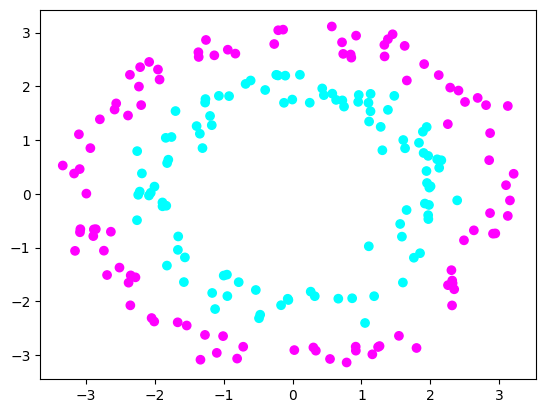

In [141]:
torus1_key1 = random.key(1234)
torus1_key2 = random.key(12345)
r = 1

def gen_torus(r, n, s1, s2, s3, s4):
    torus1_key1 = random.key(s1)
    torus1_key2 = random.key(s2)
    
    x = r * jnp.sin(random.uniform(torus1_key1, shape=(n,)) * 2 * jnp.pi)
    y = r * jnp.cos(random.uniform(torus1_key1, shape=(n,)) * 2 * jnp.pi)

    noise_key1 = random.key(s3)
    noise_key2 = random.key(s4)
    noise1 = random.normal(noise_key1, shape=(n,)) * 0.2

    noise2 = random.normal(noise_key2, shape=(n,)) * 0.2

    return jnp.array([x + noise1, y + noise2]).T

t1 = gen_torus(2, 100, 3, 1, 4, 2)
t2 = gen_torus(3, 100, 301, 3124, 24, 291)

y = jnp.concatenate([jnp.zeros((100, 1)), jnp.ones((100, 1))], axis = 0)

data = jnp.concatenate([t1, t2])

plt.scatter(data[:, 0], data[:, 1], c = y, cmap="cool")


In [142]:
key = random.key(20837143)
keys = random.split(key, num = 10)
keys.shape

(10,)

In [172]:
def initialize_params(layers):
    param_dict = {}
    
    key = random.key(20837143)
    keys = random.split(key, num = len(layers))

    for i, (a, b) in enumerate(zip(layers[:-1], layers[1:])):
        cur_keys = random.split(keys[i])
        param_dict[f'layer{i}'] = {f'W{i}': random.normal(cur_keys[0], shape=(a, b)) * jnp.sqrt(2/a), f'b{i}': jnp.zeros(shape=(b,))}
    return param_dict

params = initialize_params([2, 100, 100, 100, 1])
jax.tree.map(lambda x: x.shape, params)

{'layer0': {'W0': (2, 100), 'b0': (100,)},
 'layer1': {'W1': (100, 100), 'b1': (100,)},
 'layer2': {'W2': (100, 100), 'b2': (100,)},
 'layer3': {'W3': (100, 1), 'b3': (1,)}}

In [176]:
def relu(x):
    return jnp.maximum(0, x)

def forward(params, X):
    W0, b0 = params['layer0']['W0'], params['layer0']['b0']
    W1, b1 = params['layer1']['W1'], params['layer1']['b1']
    W2, b2 = params['layer2']['W2'], params['layer2']['b2']
    W3, b3 = params['layer3']['W3'], params['layer3']['b3']

    z0 = jnp.dot(X, W0) + b0
    h1 = relu(z0)
    z1 = jnp.dot(h1, W1) + b1
    h2 = relu(z1)
    z2 = jnp.dot(h2, W2) + b2
    h3 = relu(z2)
    z3 = jnp.dot(h3, W3) + b3

    return 1 / (1 + jnp.exp(-z3))

def loss(params, X, y):
    y_pred = forward(params, X)
    eps = 1e-7
    y_pred = jnp.clip(y_pred, eps, 1 - eps)
    return -jnp.mean(y * jnp.log(y_pred) + (1 - y) * jnp.log(1 - y_pred))

def step(params, X, y):
    LR = 0.01
    grads = jax.grad(loss)(params, X, y)
    return jax.tree.map(lambda p, g: p - LR * g, params, grads)

In [193]:
from tqdm.notebook import tqdm
from jax import random
import jax.numpy as jnp

epochs = 1000
batch_size = 32

key = random.key(0)
loss_arr = []

n = data.shape[0]

for epoch in tqdm(range(epochs), desc="Training"):
    # shuffle data each epoch
    key, subkey = random.split(key)
    perm = random.permutation(subkey, n)

    data_shuffled = data[perm]
    y_shuffled = y[perm]

    # loop through mini-batches
    for start in range(0, n, batch_size):
        end = start + batch_size

        X_batch = data_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        params = step(params, X_batch, y_batch)

    # record full-dataset loss once per epoch
    cur_loss = float(loss(params, data, y))
    loss_arr.append(cur_loss)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

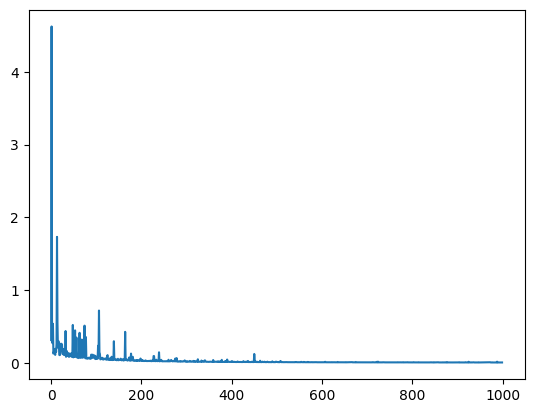

In [194]:
plt.plot(loss_arr)

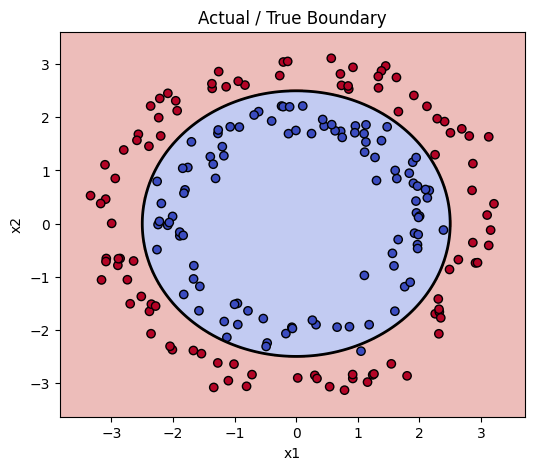

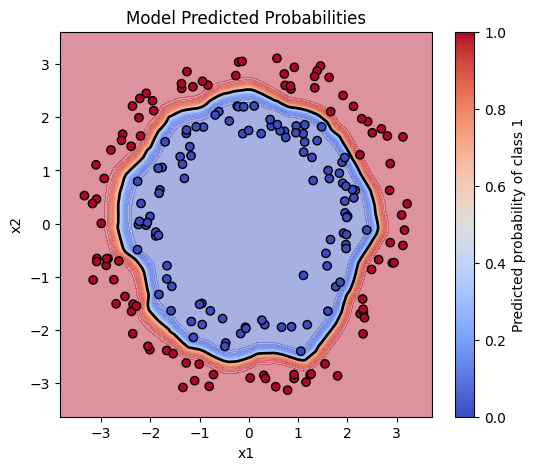

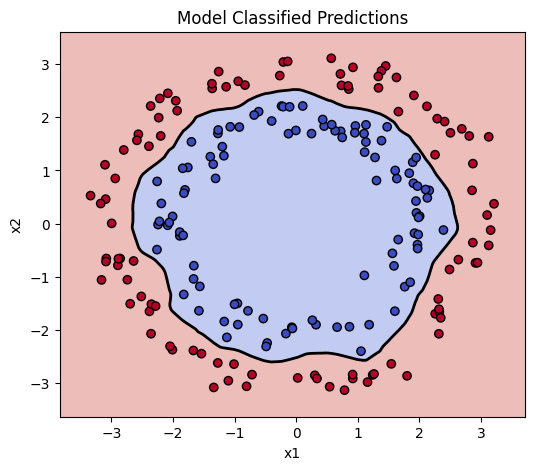

In [195]:
# asking mr gpt for this cuz i suck at plotting D:
import matplotlib.pyplot as plt
import jax.numpy as jnp

# -----------------------
# 1. Create grid
# -----------------------
x_min, x_max = data[:, 0].min() - 0.5, data[:, 0].max() + 0.5
y_min, y_max = data[:, 1].min() - 0.5, data[:, 1].max() + 0.5

xx, yy = jnp.meshgrid(
    jnp.linspace(x_min, x_max, 300),
    jnp.linspace(y_min, y_max, 300)
)

grid = jnp.stack([xx.ravel(), yy.ravel()], axis=1)

# -----------------------
# 2. Model predictions on grid
# -----------------------
grid_probs = forward(params, grid).reshape(xx.shape)
grid_classes = (grid_probs > 0.5).astype(int)

# training point predictions
train_probs = forward(params, data).squeeze()
train_classes = (train_probs > 0.5).astype(int)

# make y flat for plotting
y_flat = y.squeeze()

# -----------------------
# 3. Actual boundary
# -----------------------
# Since your true rings are radius 2 and 3, midpoint boundary is radius 2.5
r_boundary = 2.5

radius_grid = jnp.sqrt(xx**2 + yy**2)
true_grid_classes = (radius_grid > r_boundary).astype(int)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, true_grid_classes, alpha=0.35, cmap="coolwarm")
plt.contour(xx, yy, radius_grid, levels=[r_boundary], colors="black", linewidths=2)

plt.scatter(
    data[:, 0], data[:, 1],
    c=y_flat,
    cmap="coolwarm",
    edgecolors="k"
)

plt.title("Actual / True Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# -----------------------
# 4. Predicted probabilities
# -----------------------
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, grid_probs, levels=50, alpha=0.45, cmap="coolwarm")
plt.contour(xx, yy, grid_probs, levels=[0.5], colors="black", linewidths=2)

plt.scatter(
    data[:, 0], data[:, 1],
    c=y_flat,
    cmap="coolwarm",
    edgecolors="k"
)

plt.colorbar(label="Predicted probability of class 1")
plt.title("Model Predicted Probabilities")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# -----------------------
# 5. Classified predictions
# -----------------------
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, grid_classes, alpha=0.35, cmap="coolwarm")
plt.contour(xx, yy, grid_probs, levels=[0.5], colors="black", linewidths=2)

plt.scatter(
    data[:, 0], data[:, 1],
    c=train_classes,
    cmap="coolwarm",
    edgecolors="k"
)

plt.title("Model Classified Predictions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [196]:
print('final loss:', float(loss(params, data, y)))

final loss: 0.0033759381622076035
